<a href="https://colab.research.google.com/github/Le2se0hy/XAI_An/blob/main/XGBSHAP_%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# 연도별 XGBoost 성능평가 + SHAP 계산
# ============================================================

!pip install shap xgboost openpyxl -q

import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

shap.initjs()


# ============================================================
# 1. 데이터 불러오기
# ============================================================
drive.mount(
    "/content/drive",
    force_remount=True
)

file_path = (
    "/content/drive/MyDrive/비교/0912.xlsx"
)

df = pd.read_excel(file_path)

print("원본 데이터 shape:", df.shape)


# ============================================================
# 2. 변수 설정
# ============================================================
target = "log price"

year_col = "year"

years = [
    2022,
    2023,
    2024,
    2025
]

features = [
    # 주택 및 단지 특성
    "size",
    "floor",
    "unit",
    "construction",
    "parking per unit",
    "max floor",
    "heating",

    # 접근성 및 주변 환경
    "dist water",
    "dist green",
    "dist subway",
    "dist office",
    "highschool",
    "bus stop",
    "academy",

    # 지역 인구 특성
    "population",
    "median",
    "young",
    "sex ratio",
    "density",

    # 계절 더미
    "spring",
    "fall",
    "winter"
]


# ============================================================
# 3. 필요한 변수 확인
# ============================================================
required_cols = (
    features
    + [
        target,
        year_col
    ]
)

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"데이터에 다음 변수가 없습니다: {missing_cols}"
    )


# ============================================================
# 4. 분석 변수 숫자형 변환
# ============================================================
for col in required_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 5. 분석에 필요한 변수 결측치 제거
# ============================================================
df_model = (
    df
    .dropna(
        subset=required_cols
    )
    .copy()
    .reset_index(drop=True)
)

print(
    "\n최종 데이터 shape:",
    df_model.shape
)

print(
    "\n연도별 표본 수:"
)

print(
    df_model["year"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 6. XGBoost 모델 함수
# ============================================================
def create_xgb_model(
    random_state=42
):

    return XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )


# ============================================================
# 7. 결과 저장용 객체
# ============================================================
all_perf = []
all_shap = []

shap_values_by_year = {}
X_shap_by_year = {}
df_shap_by_year = {}

shap_model_by_year = {}
shap_explainer_by_year = {}

prediction_by_year = {}


# ============================================================
# 8. 연도별 분석
# ============================================================
for yr in years:

    print("\n")
    print("=" * 80)
    print(f"{yr}년 XGBoost + SHAP 분석")
    print("=" * 80)


    # --------------------------------------------------------
    # 해당 연도 데이터
    # --------------------------------------------------------
    df_year = (
        df_model[
            df_model["year"] == yr
        ]
        .copy()
        .reset_index(drop=True)
    )

    print(
        f"전체 표본 수: "
        f"{len(df_year):,}"
    )

    if len(df_year) < 30:

        print(
            "표본 수가 부족하여 "
            "분석에서 제외합니다."
        )

        continue


    X = (
        df_year[
            features
        ]
        .copy()
    )

    y = (
        df_year[
            target
        ]
        .copy()
    )


    # ========================================================
    # 8-1. Train 70% / Test 30%
    # ========================================================
    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )


    # ========================================================
    # 8-2. 성능평가용 XGBoost
    # ========================================================
    performance_model = (
        create_xgb_model(
            random_state=42
        )
    )

    performance_model.fit(
        X_train,
        y_train
    )


    pred_train = (
        performance_model.predict(
            X_train
        )
    )

    pred_test = (
        performance_model.predict(
            X_test
        )
    )


    train_r2 = r2_score(
        y_train,
        pred_train
    )

    test_r2 = r2_score(
        y_test,
        pred_test
    )


    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            pred_train
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )


    perf_df = pd.DataFrame([{
        "Year":
            yr,

        "Total_N":
            len(X),

        "Train_N":
            len(X_train),

        "Test_N":
            len(X_test),

        "Train_R2":
            train_r2,

        "Train_RMSE":
            train_rmse,

        "Test_R2":
            test_r2,

        "Test_RMSE":
            test_rmse
    }])


    all_perf.append(
        perf_df
    )


    print(
        f"\n[{yr}년 Train]"
    )

    print(
        f"R²   : {train_r2:.4f}"
    )

    print(
        f"RMSE : {train_rmse:.4f}"
    )


    print(
        f"\n[{yr}년 Test]"
    )

    print(
        f"R²   : {test_r2:.4f}"
    )

    print(
        f"RMSE : {test_rmse:.4f}"
    )


    # ========================================================
    # 8-3. Test 예측값 저장
    # ========================================================
    prediction_by_year[
        yr
    ] = pd.DataFrame({

        "Actual":
            y_test.to_numpy(),

        "Predicted":
            pred_test,

        "Residual":
            y_test.to_numpy()
            - pred_test
    })


    # ========================================================
    # 8-4. 해당 연도 전체 데이터로 SHAP 모델 학습
    # ========================================================
    shap_model = (
        create_xgb_model(
            random_state=42
        )
    )

    shap_model.fit(
        X,
        y
    )


    # ========================================================
    # 8-5. SHAP 계산
    # ========================================================
    explainer = shap.TreeExplainer(
        shap_model
    )

    shap_values = (
        explainer.shap_values(
            X
        )
    )


    if isinstance(
        shap_values,
        list
    ):
        shap_values = (
            shap_values[0]
        )


    shap_values = np.asarray(
        shap_values
    )


    if shap_values.shape != X.shape:

        raise ValueError(
            f"{yr}년 X와 SHAP 값의 "
            "크기가 일치하지 않습니다."
        )


    # ========================================================
    # 8-6. 다음 코드셀에서 사용할 결과 저장
    # ========================================================
    shap_values_by_year[
        yr
    ] = shap_values

    X_shap_by_year[
        yr
    ] = (
        X
        .copy()
        .reset_index(drop=True)
    )

    df_shap_by_year[
        yr
    ] = (
        df_year
        .copy()
        .reset_index(drop=True)
    )

    shap_model_by_year[
        yr
    ] = shap_model

    shap_explainer_by_year[
        yr
    ] = explainer


    # ========================================================
    # 8-7. 평균 절대 SHAP
    # ========================================================
    mean_abs_shap = pd.DataFrame({

        "Year":
            yr,

        "Feature":
            features,

        "MeanAbsSHAP":
            np.abs(
                shap_values
            ).mean(axis=0)
    })


    mean_abs_shap = (
        mean_abs_shap
        .sort_values(
            "MeanAbsSHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )


    all_shap.append(
        mean_abs_shap
    )


    print(
        f"\n[{yr}년 평균 절대 SHAP]"
    )

    display(
        mean_abs_shap
    )


# ============================================================
# 9. 연도별 성능 비교표
# ============================================================
performance_table = pd.concat(
    all_perf,
    ignore_index=True
)

print("\n")
print("=" * 80)
print("연도별 XGBoost 성능")
print("=" * 80)

display(
    performance_table
)


# ============================================================
# 10. 전체 SHAP 중요도 표
# ============================================================
shap_importance_table = pd.concat(
    all_shap,
    ignore_index=True
)

print("\n")
print("=" * 80)
print("연도별 SHAP 중요도")
print("=" * 80)

display(
    shap_importance_table
)

Mounted at /content/drive
원본 데이터 shape: (188853, 45)

최종 데이터 shape: (188853, 45)

연도별 표본 수:
year
2022    12535
2023    35403
2024    57482
2025    83433
Name: count, dtype: int64


2022년 XGBoost + SHAP 분석
전체 표본 수: 12,535

[2022년 Train]
R²   : 0.9569
RMSE : 0.0957

[2022년 Test]
R²   : 0.8969
RMSE : 0.1469

[2022년 평균 절대 SHAP]


,Year,Feature,MeanAbsSHAP
0,2022,young,0.138092
1,2022,unit,0.135809
2,2022,construction,0.088115
3,2022,median,0.065178
4,2022,size,0.049889
5,2022,population,0.044763
6,2022,parking per unit,0.043309
7,2022,sex ratio,0.034265
8,2022,density,0.034077
9,2022,max floor,0.025879




2023년 XGBoost + SHAP 분석
전체 표본 수: 35,403

[2023년 Train]
R²   : 0.9591
RMSE : 0.0887

[2023년 Test]
R²   : 0.9363
RMSE : 0.1094

[2023년 평균 절대 SHAP]


,Year,Feature,MeanAbsSHAP
0,2023,young,0.143494
1,2023,construction,0.083708
2,2023,unit,0.082335
3,2023,size,0.063484
4,2023,median,0.061541
5,2023,parking per unit,0.041478
6,2023,population,0.038967
7,2023,dist subway,0.036048
8,2023,heating,0.034812
9,2023,highschool,0.033332




2024년 XGBoost + SHAP 분석
전체 표본 수: 57,482

[2024년 Train]
R²   : 0.9635
RMSE : 0.0882

[2024년 Test]
R²   : 0.9539
RMSE : 0.1003

[2024년 평균 절대 SHAP]


,Year,Feature,MeanAbsSHAP
0,2024,young,0.153451
1,2024,construction,0.095432
2,2024,unit,0.071339
3,2024,median,0.070816
4,2024,size,0.066465
5,2024,parking per unit,0.041450
6,2024,population,0.039665
7,2024,dist subway,0.038454
8,2024,density,0.037953
9,2024,highschool,0.035483




2025년 XGBoost + SHAP 분석
전체 표본 수: 83,433

[2025년 Train]
R²   : 0.9548
RMSE : 0.1008

[2025년 Test]
R²   : 0.9453
RMSE : 0.1103

[2025년 평균 절대 SHAP]


,Year,Feature,MeanAbsSHAP
0,2025,young,0.159738
1,2025,construction,0.098234
2,2025,unit,0.084931
3,2025,median,0.080314
4,2025,size,0.071498
5,2025,density,0.049282
6,2025,dist subway,0.041008
7,2025,parking per unit,0.040770
8,2025,highschool,0.040385
9,2025,population,0.034766




연도별 XGBoost 성능


,Year,Total_N,Train_N,Test_N,Train_R2,Train_RMSE,Test_R2,Test_RMSE
0,2022,12535,8774,3761,0.956886,0.095704,0.896926,0.146850
1,2023,35403,24782,10621,0.959090,0.088678,0.936305,0.109423
2,2024,57482,40237,17245,0.963510,0.088169,0.953873,0.100272
3,2025,83433,58403,25030,0.954796,0.100850,0.945269,0.110334




연도별 SHAP 중요도


,Year,Feature,MeanAbsSHAP
0,2022,young,0.138092
1,2022,unit,0.135809
2,2022,construction,0.088115
3,2022,median,0.065178
4,2022,size,0.049889
...,...,...,...
83,2025,bus stop,0.011819
84,2025,spring,0.010433
85,2025,dist water,0.005630
86,2025,winter,0.004770


In [3]:
# ============================================================
# 2022~2025 위도·경도 + 모든 변수별 SHAP 값 엑셀 저장
#
# 코드셀 1 실행 후 실행
# ============================================================

import os
import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 1. 저장 폴더
# ============================================================
output_dir = (
    "/content/drive/MyDrive/0920_SHAP"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================================
# 2. 좌표 변수
# ============================================================
coordinate_cols = [
    "Longitude",
    "Latitude"
]


# ============================================================
# 3. 연도별 SHAP 결과 저장
# ============================================================
for analysis_year in years:

    print("\n")
    print("=" * 80)
    print(
        f"{analysis_year}년 SHAP "
        "데이터 저장"
    )
    print("=" * 80)


    # --------------------------------------------------------
    # 코드셀 1 결과 확인
    # --------------------------------------------------------
    if (
        analysis_year
        not in shap_values_by_year
    ):
        print(
            f"{analysis_year}년 SHAP 결과가 없어 "
            "건너뜁니다."
        )
        continue


    # --------------------------------------------------------
    # 해당 연도 데이터
    # --------------------------------------------------------
    df_selected_year = (
        df_shap_by_year[
            analysis_year
        ]
        .copy()
        .reset_index(drop=True)
    )


    X_selected = (
        X_shap_by_year[
            analysis_year
        ]
        .copy()
        .reset_index(drop=True)
    )


    selected_shap_values = (
        shap_values_by_year[
            analysis_year
        ]
    )


    selected_model = (
        shap_model_by_year[
            analysis_year
        ]
    )


    selected_explainer = (
        shap_explainer_by_year[
            analysis_year
        ]
    )


    y_selected = (
        df_selected_year[
            target
        ]
        .copy()
        .reset_index(drop=True)
    )


    print(
        "데이터 수:",
        len(df_selected_year)
    )


    # ========================================================
    # 4. 좌표 확인
    # ========================================================
    missing_coordinate_cols = [

        col

        for col in coordinate_cols

        if col
        not in df_selected_year.columns
    ]


    if missing_coordinate_cols:

        raise ValueError(
            "다음 좌표 변수가 없습니다: "
            f"{missing_coordinate_cols}"
        )


    for col in coordinate_cols:

        df_selected_year[col] = (
            pd.to_numeric(
                df_selected_year[col],
                errors="coerce"
            )
        )


    # ========================================================
    # 5. 모든 변수 SHAP 값
    # ========================================================
    shap_columns = [

        f"{feature}_SHAP"

        for feature in features
    ]


    shap_values_df = pd.DataFrame(
        selected_shap_values,
        columns=shap_columns
    )


    # ========================================================
    # 6. Young Population SHAP
    # ========================================================
    young_index = (
        features.index(
            "young"
        )
    )


    young_pop_shap = pd.Series(

        selected_shap_values[
            :,
            young_index
        ],

        name="YoungPop_Shapley_Value"
    )


    # ========================================================
    # 7. 실제값·예측값·기준값
    # ========================================================
    predicted_values = (
        selected_model.predict(
            X_selected
        )
    )


    expected_value = (
        selected_explainer.expected_value
    )


    if isinstance(
        expected_value,
        (list, np.ndarray)
    ):

        expected_value = (
            np.asarray(
                expected_value
            )
            .flatten()[0]
        )


    model_result_df = pd.DataFrame({

        "Actual_price":
            y_selected.to_numpy(),

        "Predicted_price":
            predicted_values,

        "SHAP_Expected_Value":
            expected_value
    })


    # ========================================================
    # 8. 기본 정보
    # ========================================================
    basic_info_df = pd.DataFrame({

        "year":
            np.repeat(
                analysis_year,
                len(df_selected_year)
            ),

        "Longitude":
            df_selected_year[
                "Longitude"
            ].to_numpy(),

        "Latitude":
            df_selected_year[
                "Latitude"
            ].to_numpy()
    })


    # ========================================================
    # 9. 최종 거래별 SHAP 자료
    # ========================================================
    shap_export_df = pd.concat(
        [
            basic_info_df,

            young_pop_shap,

            model_result_df,

            X_selected,

            shap_values_df
        ],
        axis=1
    )


    # ========================================================
    # 10. 평균 절대 SHAP
    # ========================================================
    mean_abs_shap_df = pd.DataFrame({

        "Year":
            analysis_year,

        "Feature":
            features,

        "MeanAbsSHAP":
            np.abs(
                selected_shap_values
            ).mean(axis=0)
    })


    mean_abs_shap_df = (
        mean_abs_shap_df
        .sort_values(
            "MeanAbsSHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 11. 파일명
    # ========================================================
    output_shap_path = (

        f"{output_dir}/"
        f"XGB_SHAP_{analysis_year}.xlsx"
    )


    # ========================================================
    # 12. 엑셀 저장
    # ========================================================
    with pd.ExcelWriter(
        output_shap_path,
        engine="openpyxl"
    ) as writer:


        shap_export_df.to_excel(
            writer,
            sheet_name=f"SHAP_{analysis_year}",
            index=False
        )


        mean_abs_shap_df.to_excel(
            writer,
            sheet_name=f"Importance_{analysis_year}",
            index=False
        )


    # ========================================================
    # 13. 결과 확인
    # ========================================================
    print(
        "저장 데이터 크기:",
        shap_export_df.shape
    )

    print(
        "SHAP 변수 수:",
        len(shap_columns)
    )

    print(
        "저장 완료:",
        output_shap_path
    )


print("\n")
print("=" * 80)
print("2022~2025 SHAP 저장 완료")
print("=" * 80)



2022년 SHAP 데이터 저장
데이터 수: 12535
저장 데이터 크기: (12535, 51)
SHAP 변수 수: 22
저장 완료: /content/drive/MyDrive/0920_SHAP/XGB_SHAP_2022.xlsx


2023년 SHAP 데이터 저장
데이터 수: 35403
저장 데이터 크기: (35403, 51)
SHAP 변수 수: 22
저장 완료: /content/drive/MyDrive/0920_SHAP/XGB_SHAP_2023.xlsx


2024년 SHAP 데이터 저장
데이터 수: 57482
저장 데이터 크기: (57482, 51)
SHAP 변수 수: 22
저장 완료: /content/drive/MyDrive/0920_SHAP/XGB_SHAP_2024.xlsx


2025년 SHAP 데이터 저장
데이터 수: 83433
저장 데이터 크기: (83433, 51)
SHAP 변수 수: 22
저장 완료: /content/drive/MyDrive/0920_SHAP/XGB_SHAP_2025.xlsx


2022~2025 SHAP 저장 완료



[2022년 SHAP Summary Plot]


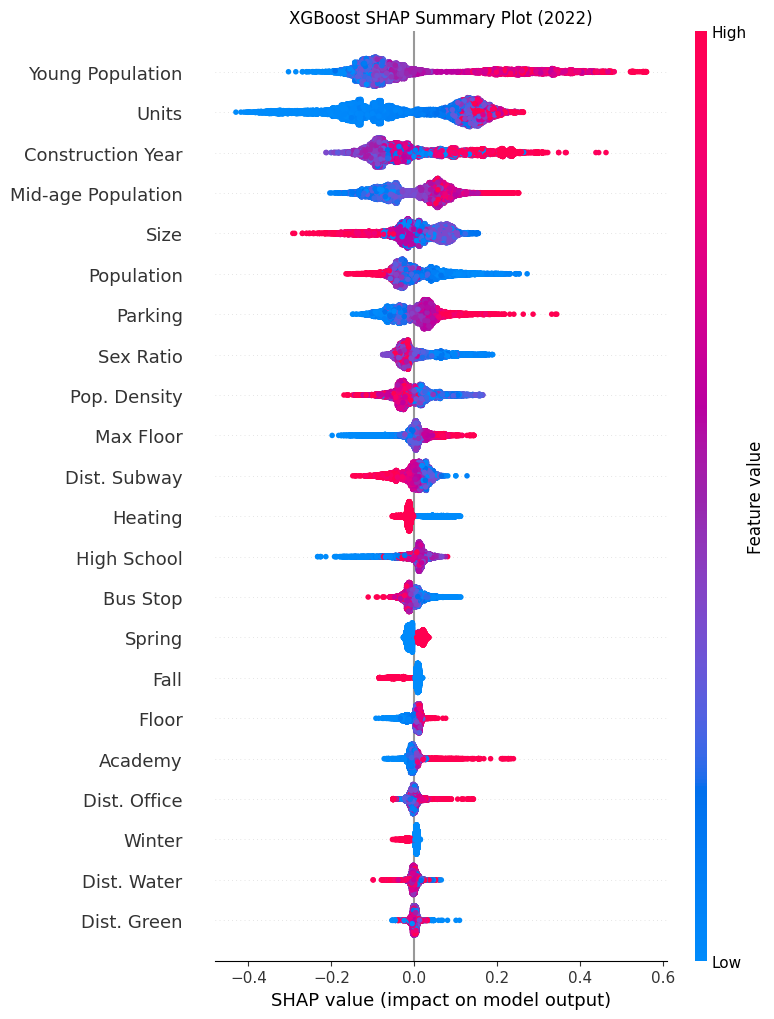


[2022년 Mean Absolute SHAP]


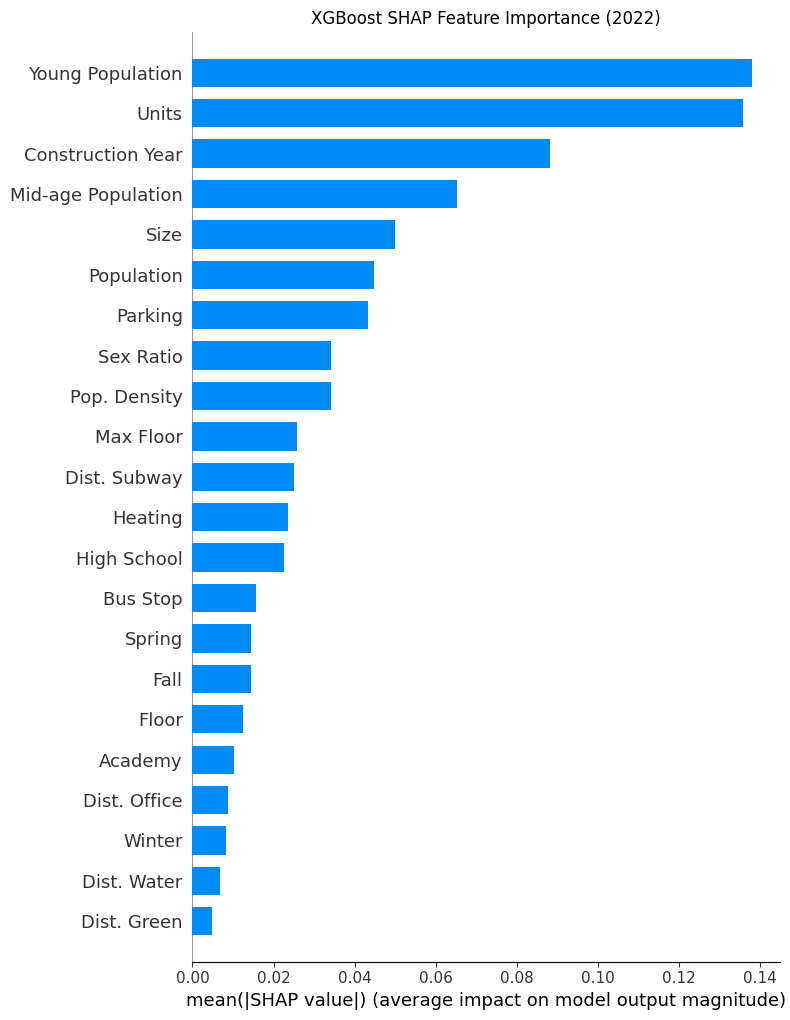


[2023년 SHAP Summary Plot]


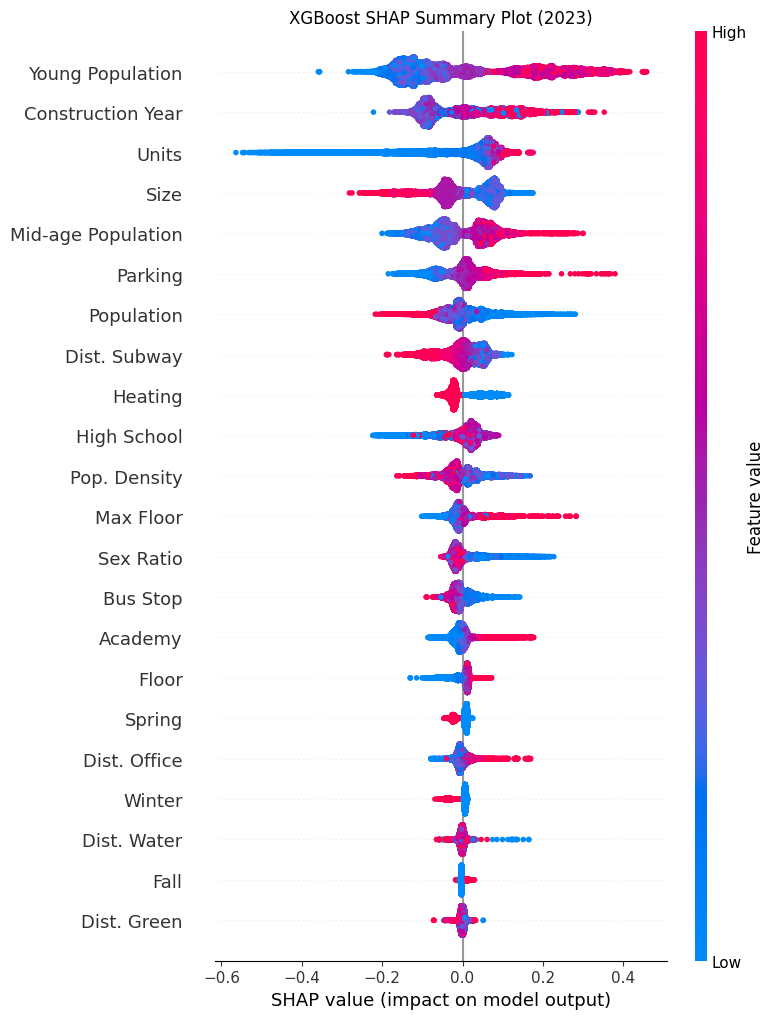


[2023년 Mean Absolute SHAP]


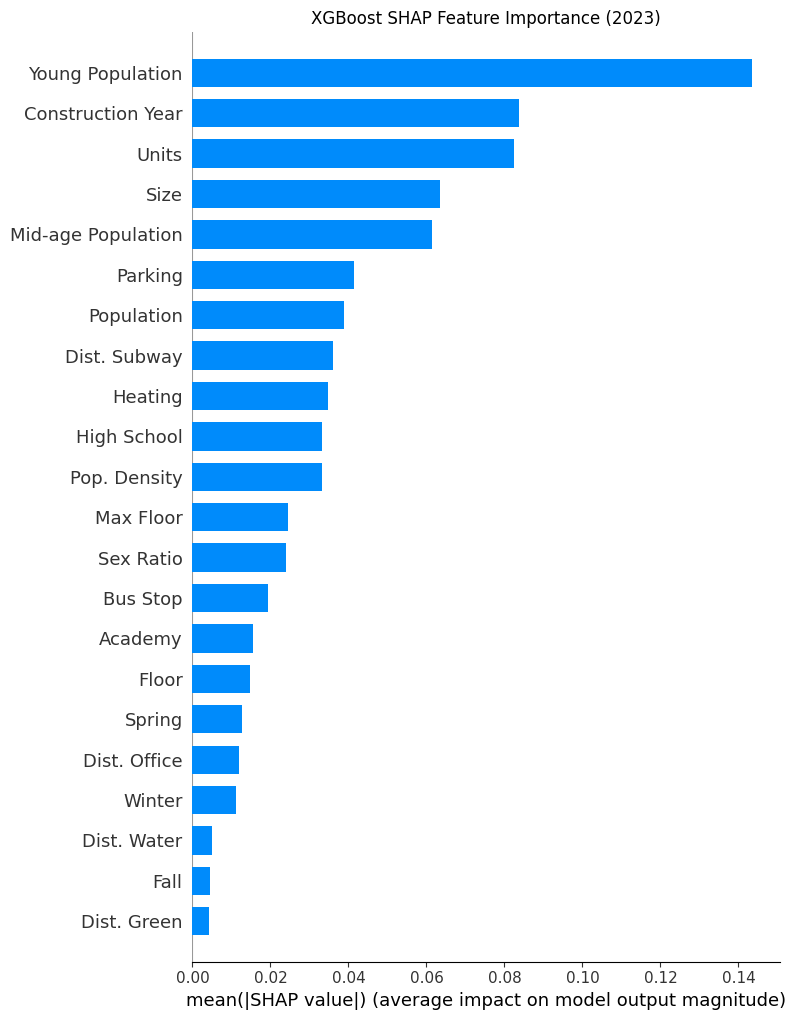


[2024년 SHAP Summary Plot]


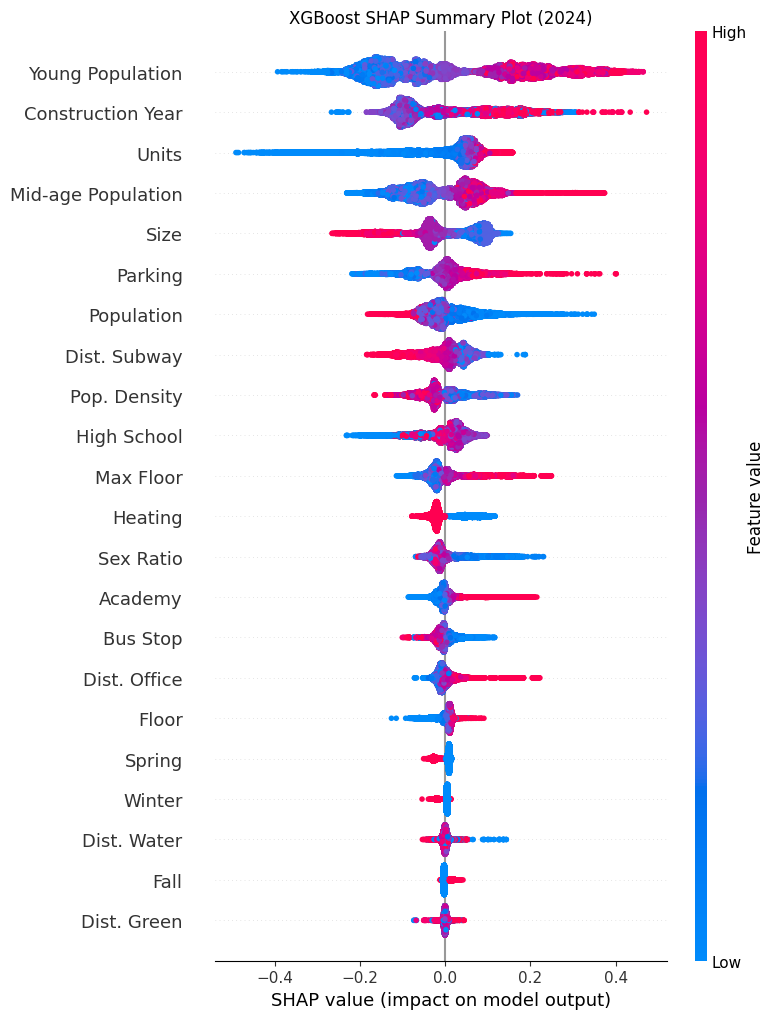


[2024년 Mean Absolute SHAP]


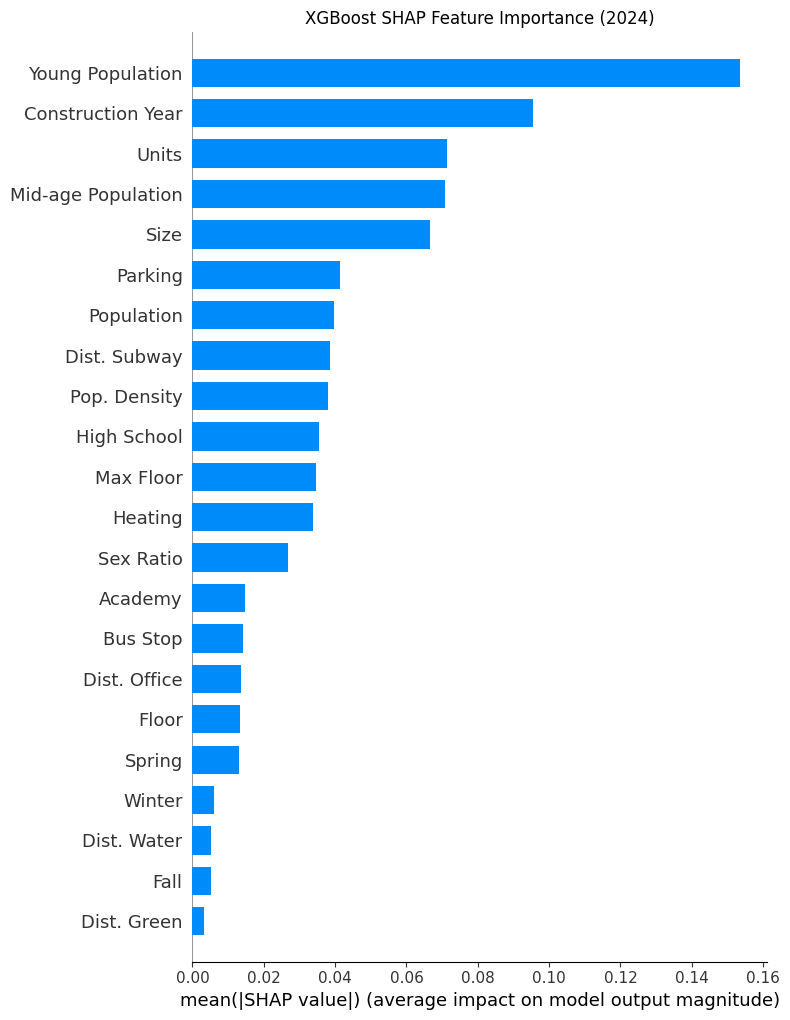


[2025년 SHAP Summary Plot]


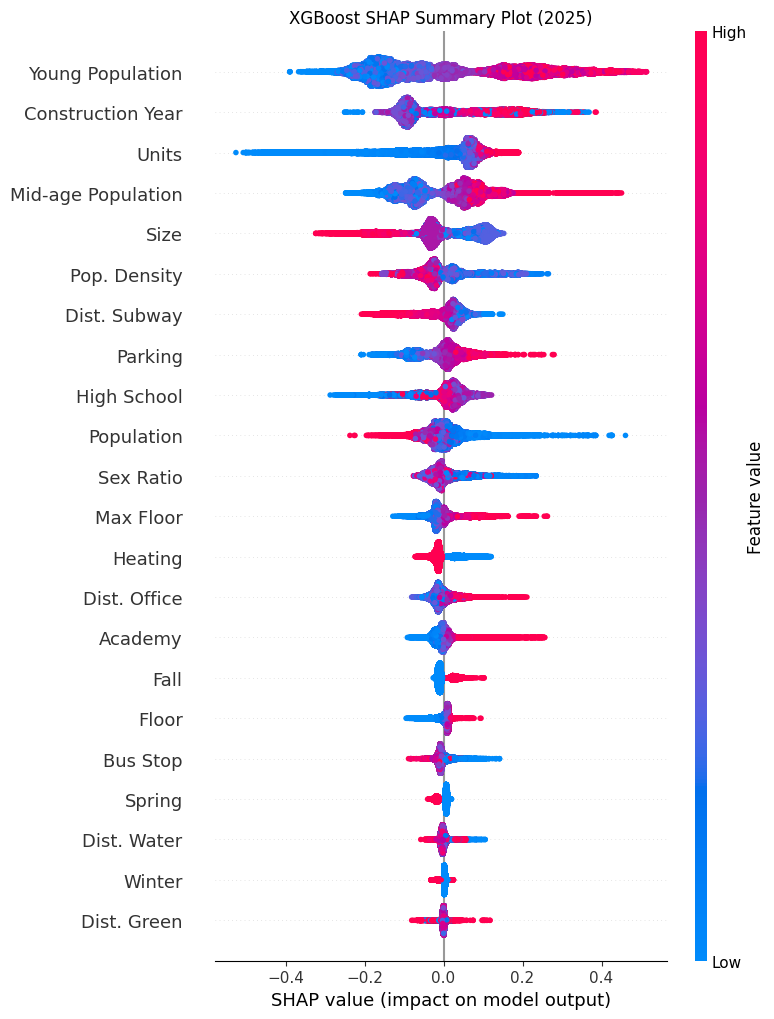


[2025년 Mean Absolute SHAP]


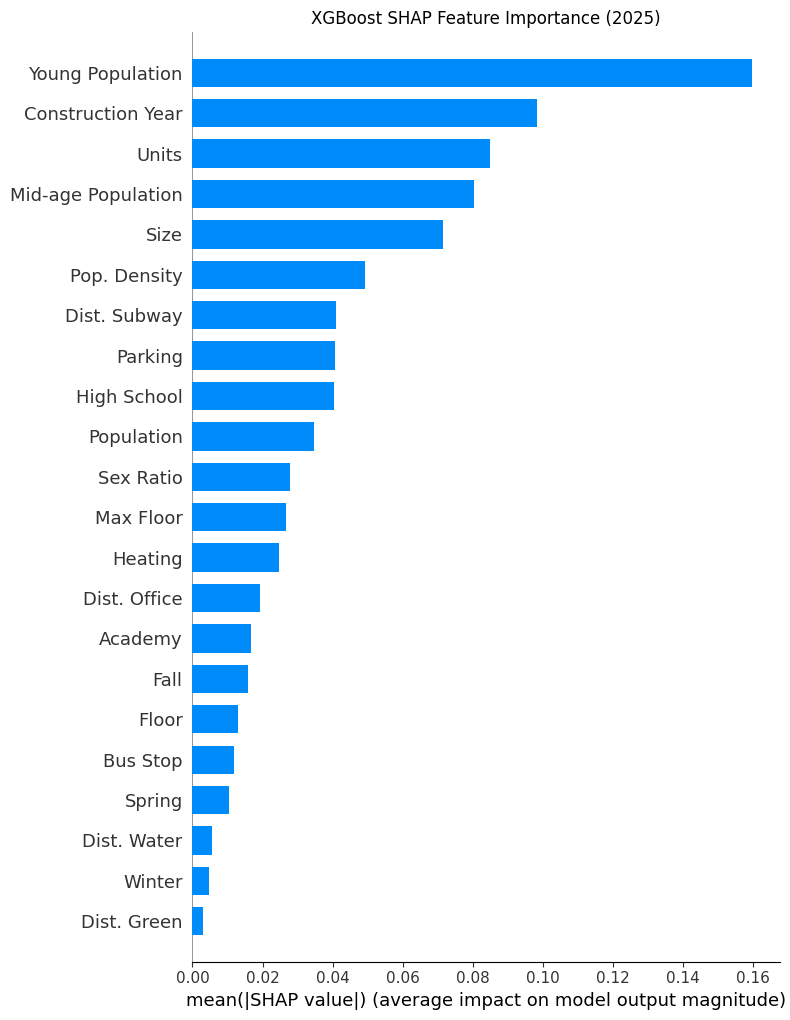

In [6]:
# ============================================================
# SHAP 그래프 변수명 변경
#
# 1. Beeswarm Summary Plot
# 2. Mean Absolute SHAP Bar Plot
#
# 코드셀 1 실행 후 실행
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


# ============================================================
# 1. 그래프 표시용 변수명
# ============================================================
feature_label_map = {

    "log price":
        "Price",

    "size":
        "Size",

    "floor":
        "Floor",

    "unit":
        "Units",

    "construction":
        "Construction Year",

    "parking per unit":
        "Parking",

    "max floor":
        "Max Floor",

    "heating":
        "Heating",

    "dist water":
        "Dist. Water",

    "dist green":
        "Dist. Green",

    "dist subway":
        "Dist. Subway",

    "dist office":
        "Dist. Office",

    "highschool":
        "High School",

    "bus stop":
        "Bus Stop",

    "academy":
        "Academy",

    "population":
        "Population",

    "median":
        "Mid-age Population",

    "young":
        "Young Population",

    "sex ratio":
        "Sex Ratio",

    "density":
        "Pop. Density",

    "spring":
        "Spring",

    "fall":
        "Fall",

    "winter":
        "Winter"
}


# ============================================================
# 2. 연도별 SHAP 그래프
# ============================================================
for yr in years:

    if yr not in shap_values_by_year:

        print(
            f"{yr}년 SHAP 결과가 없어 "
            "건너뜁니다."
        )

        continue


    shap_values = (
        shap_values_by_year[
            yr
        ]
    )


    X_plot = (
        X_shap_by_year[
            yr
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 그래프 표시용 변수명으로 변경
    # 실제 원자료의 변수명은 바뀌지 않음
    # --------------------------------------------------------
    X_plot.columns = [

        feature_label_map.get(
            col,
            col
        )

        for col
        in X_plot.columns
    ]


    # ========================================================
    # 3. SHAP Summary Plot - Beeswarm
    # ========================================================
    print(
        f"\n[{yr}년 "
        "SHAP Summary Plot]"
    )


    plt.figure(
        figsize=(9, 8)
    )


    shap.summary_plot(
        shap_values,
        X_plot,
        max_display=len(features),
        show=False
    )


    plt.title(
        f"XGBoost SHAP Summary Plot ({yr})"
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 4. SHAP Mean Absolute Value - Bar
    # ========================================================
    print(
        f"\n[{yr}년 "
        "Mean Absolute SHAP]"
    )


    plt.figure(
        figsize=(9, 8)
    )


    shap.summary_plot(
        shap_values,
        X_plot,
        plot_type="bar",
        max_display=len(features),
        show=False
    )


    plt.title(
        f"XGBoost SHAP Feature Importance ({yr})"
    )


    plt.tight_layout()

    plt.show()